In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns

In [22]:
data = {
    'Actual': [1, 0, 1, 1, 0, 0, 1, 0, 1, 0],
    'Predicted_Probability': [0.92, 0.35, 0.87, 0.78, 0.40, 0.55, 0.82, 0.25, 0.91, 0.48]
}

df = pd.DataFrame(data)
threshold = 0.70

In [23]:
df['Model_Score_Threshold'] = (df['Predicted_Probability'] >= threshold).astype(int)

print("\nSTEP 2: CLASSIFICATION TABLE")
print(f"{'SR. No':<8} {'Actual':<8} {'Pred Prob':<12} {'Model Score (0/1)':<18}")
print("-" * 55)
for i in range(len(df)):
    print(f"{i+1:<8} {df.iloc[i]['Actual']:<8} {df.iloc[i]['Predicted_Probability']:<12} {df.iloc[i]['Model_Score_Threshold']:<18}")


STEP 2: CLASSIFICATION TABLE
SR. No   Actual   Pred Prob    Model Score (0/1) 
-------------------------------------------------------
1        1.0      0.92         1.0               
2        0.0      0.35         0.0               
3        1.0      0.87         1.0               
4        1.0      0.78         1.0               
5        0.0      0.4          0.0               
6        0.0      0.55         0.0               
7        1.0      0.82         1.0               
8        0.0      0.25         0.0               
9        1.0      0.91         1.0               
10       0.0      0.48         0.0               


In [24]:
actual = df['Actual']
predicted = df['Model_Score_Threshold']

TP = sum((actual == 1) & (predicted == 1))
TN = sum((actual == 0) & (predicted == 0))
FP = sum((actual == 0) & (predicted == 1))
FN = sum((actual == 1) & (predicted == 0))

print(f"\nSTEP 3: CONFUSION MATRIX")
print(f"TP = {TP}, TN = {TN}, FP = {FP}, FN = {FN}")
print(f"\n{'':20} {'Predicted Rel (1)':<15} {'Predicted Non-Rel (0)':<15}")
print(f"{'True Relevant (1)':<20} {'TP = ' + str(TP):<15} {'FN = ' + str(FN):<15}")
print(f"{'True Non-Relevant (0)':<20} {'FP = ' + str(FP):<15} {'TN = ' + str(TN):<15}")


STEP 3: CONFUSION MATRIX
TP = 5, TN = 5, FP = 0, FN = 0

                     Predicted Rel (1) Predicted Non-Rel (0)
True Relevant (1)    TP = 5          FN = 0         
True Non-Relevant (0) FP = 0          TN = 5         


In [25]:
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
tpr = recall  # TPR = Recall

print(f"\nSTEP 4: PERFORMANCE METRICS")
print(f"Precision = {precision:.4f}")
print(f"Recall = {recall:.4f}")
print(f"False Positive Rate (FPR) = {fpr:.4f}")
print(f"True Positive Rate (TPR) = {tpr:.4f}")


STEP 4: PERFORMANCE METRICS
Precision = 1.0000
Recall = 1.0000
False Positive Rate (FPR) = 0.0000
True Positive Rate (TPR) = 1.0000


In [26]:
def calculate_metrics_at_threshold(actual, predicted_prob, thresh):
    predicted_binary = (predicted_prob >= thresh).astype(int)
    tp = sum((actual == 1) & (predicted_binary == 1))
    tn = sum((actual == 0) & (predicted_binary == 0))
    fp = sum((actual == 0) & (predicted_binary == 1))
    fn = sum((actual == 1) & (predicted_binary == 0))
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return tpr, fpr

thresholds = [1.0, 0.9, 0.7, 0.5, 0.3, 0.1]
tpr_values, fpr_values = [], []

In [27]:
print(f"\nSTEP 5: ROC CURVE CALCULATION")
print(f"{'Threshold':<10} {'TPR':<10} {'FPR':<10}")
print("-" * 30)
for thresh in thresholds:
    tpr_val, fpr_val = calculate_metrics_at_threshold(actual, df['Predicted_Probability'], thresh)
    tpr_values.append(tpr_val)
    fpr_values.append(fpr_val)
    print(f"{thresh:<10} {tpr_val:<10.4f} {fpr_val:<10.4f}")


STEP 5: ROC CURVE CALCULATION
Threshold  TPR        FPR       
------------------------------
1.0        0.0000     0.0000    
0.9        0.4000     0.0000    
0.7        1.0000     0.0000    
0.5        1.0000     0.2000    
0.3        1.0000     0.8000    
0.1        1.0000     1.0000    


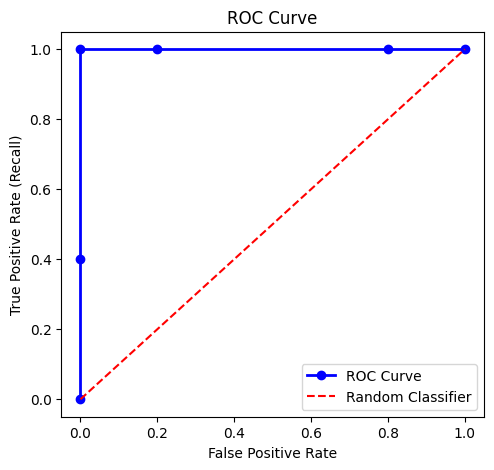

In [28]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_values, tpr_values, 'bo-', linewidth=2, markersize=6, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()

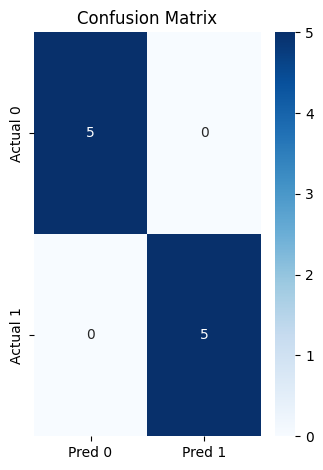

In [29]:
plt.subplot(1, 2, 2)
cm = [[TN, FP], [FN, TP]]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [30]:
fpr_sklearn, tpr_sklearn, _ = roc_curve(actual, df['Predicted_Probability'])
auc_value = auc(fpr_sklearn, tpr_sklearn)

print(f"\nFINAL RESULTS SUMMARY")
print("=" * 50)
print(f"Threshold: {threshold}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"FPR: {fpr:.4f}")
print(f"AUC: {auc_value:.4f}")


FINAL RESULTS SUMMARY
Threshold: 0.7
Precision: 1.0000
Recall: 1.0000
FPR: 0.0000
AUC: 1.0000


### Conclusion

In this experiment, we evaluated the performance of an Information Retrieval model using **Precision, Recall, ROC, and AUC**. The confusion matrix helped us identify true and false classifications, while Precision and Recall highlighted the balance between retrieving relevant documents and minimizing false positives. The ROC curve provided a graphical view of model performance across thresholds, and the **AUC value close to 1 indicated good model performance**. Overall, these evaluation metrics allow us to assess retrieval effectiveness and guide improvements in IR systems.
